In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
sentiment= pd.read_csv("fear_greed_index.csv")   #dataset_1
trades= pd.read_csv("historical_data.csv")   #dataset_2

In [4]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [7]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [8]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [9]:
sentiment= sentiment[['date','classification']]

In [12]:
# sentiment.head(10)

,date,classification
0,2018-02-01,Fear
1,2018-02-02,Extreme Fear
2,2018-02-03,Fear
3,2018-02-04,Extreme Fear
4,2018-02-05,Extreme Fear
5,2018-02-06,Extreme Fear
6,2018-02-07,Fear
7,2018-02-08,Fear
8,2018-02-09,Fear
9,2018-02-10,Neutral


In [13]:
sentiment['classification'].unique()

array(['Fear', 'Extreme Fear', 'Neutral', 'Greed', 'Extreme Greed'],
      dtype=object)

In [14]:
sentiment['sentiment']=sentiment['classification'].replace({'Extreme Fear': 'Fear', 'Extreme Greed':'Greed'})

In [15]:
sentiment['sentiment'].unique()

array(['Fear', 'Neutral', 'Greed'], dtype=object)

In [16]:
sentiment['date']=pd.to_datetime(sentiment['date'])

In [17]:
# sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            2644 non-null   datetime64[ns]
 1   classification  2644 non-null   object        
 2   sentiment       2644 non-null   object        
dtypes: datetime64[ns](1), object(2)
memory usage: 62.1+ KB


In [20]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)
# trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

In [21]:
trades['trade_date'] = trades['Timestamp IST'].dt.date
trades[['Timestamp IST','trade_date']].head()

,Timestamp IST,trade_date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [23]:
sentiment['date'].head()

,date
0,2018-02-01
1,2018-02-02
2,2018-02-03
3,2018-02-04
4,2018-02-05


In [22]:

trades['trade_date'].head()

,trade_date
0,2024-12-02
1,2024-12-02
2,2024-12-02
3,2024-12-02
4,2024-12-02


In [25]:
sentiment['date'] = sentiment['date'].dt.date

In [26]:
merged = pd.merge(
    trades,
    sentiment[['date','sentiment']],
    left_on='trade_date',
    right_on='date',
    how='left'
)
merged[['trade_date','sentiment']].head(10)

,trade_date,sentiment
0,2024-12-02,Greed
1,2024-12-02,Greed
2,2024-12-02,Greed
3,2024-12-02,Greed
4,2024-12-02,Greed
5,2024-12-02,Greed
6,2024-12-02,Greed
7,2024-12-02,Greed
8,2024-12-02,Greed
9,2024-12-02,Greed


#***Average Trader Profitability by Market Sentiment***

In [28]:
merged.groupby('sentiment')['Closed PnL'].mean()

,Closed PnL
sentiment,
Fear,49.212077
Greed,53.882281
Neutral,34.307718


In [29]:
merged['sentiment'].value_counts()

,count
sentiment,
Greed,90295
Fear,83237
Neutral,37686


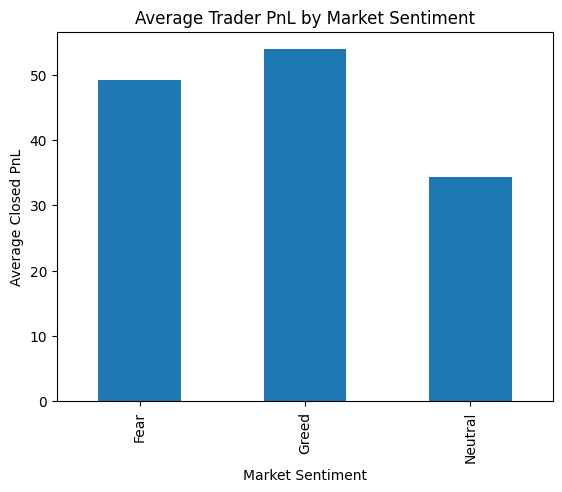

In [30]:
import matplotlib.pyplot as plt

merged.groupby('sentiment')['Closed PnL'].mean().plot(kind='bar')

plt.title("Average Trader PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

Insights:
1. Traders achieve the highest average profitability in Greed markets (≈53.9).

2. Fear markets also support relatively strong performance (≈49.2).

3. Neutral markets consistently underperform with the lowest average PnL (≈34.3).

#***Trading Outcomes by Sentiment***

In [33]:
merged['trade_result'] = merged['Closed PnL'].apply(lambda x: 'Profit' if x > 0 else 'Loss')

In [38]:
merged[['Closed PnL','trade_result']].head()

,Closed PnL,trade_result
0,0.0,Loss
1,0.0,Loss
2,0.0,Loss
3,0.0,Loss
4,0.0,Loss


In [39]:
profit_distribution = merged.groupby(['sentiment','trade_result']).size()

print(profit_distribution)

sentiment  trade_result
Fear       Loss            49287
           Profit          33950
Greed      Loss            52343
           Profit          37952
Neutral    Loss            22725
           Profit          14961
dtype: int64


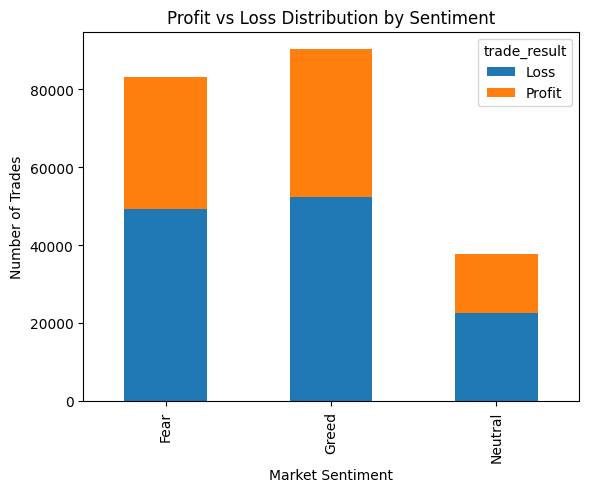

In [43]:
merged.groupby(['sentiment','trade_result']).size().unstack().plot(kind='bar', stacked=True)

plt.title("Profit vs Loss Distribution by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

Insights:

Across all sentiment categories, loss-making trades exceed profitable trades.

Fear: 49,287 losses vs 33,950 profits

Greed: 52,343 losses vs 37,952 profits

Neutral: 22,725 losses vs 14,961 profits

This imbalance highlights the structural challenge of sustaining consistent profitability in trading, regardless of sentiment.

Even in Greed markets (where average PnL is highest), the majority of trades still end in losses.

#***Trader Behaviour Analysis (Buy vs Sell)***

In [41]:
merged.groupby(['sentiment','Side']).size()

sentiment  Side
Fear       BUY     41205
           SELL    42032
Greed      BUY     42516
           SELL    47779
Neutral    BUY     18969
           SELL    18717
dtype: int64

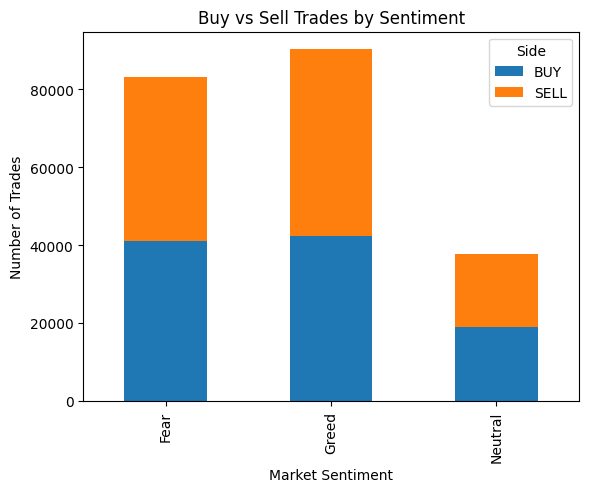

In [44]:
merged.groupby(['sentiment','Side']).size().unstack().plot(kind='bar', stacked=True)

plt.title("Buy vs Sell Trades by Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

Insights:

1. Buy and sell trades are relatively balanced across sentiments.
2. Greed markets show the highest trading activity.
3. Sell trades slightly exceed buy trades, suggesting profit-taking or short-selling strategies.


#***Risk Analysis (Trade Size)***

In [47]:
merged.groupby(['sentiment','Coin']).size().sort_values(ascending=False).head(10)

sentiment  Coin
Fear       HYPE    38229
Greed      @107    18801
Neutral    HYPE    17324
Greed      HYPE    12452
Fear       BTC     11635
Greed      BTC      9676
Fear       @107     6981
           SOL      5792
Greed      ETH      5598
Neutral    BTC      4753
dtype: int64

In [48]:
merged.groupby('sentiment')['Size USD'].mean()

,Size USD
sentiment,
Fear,7182.011019
Greed,4574.424490
Neutral,4782.732661


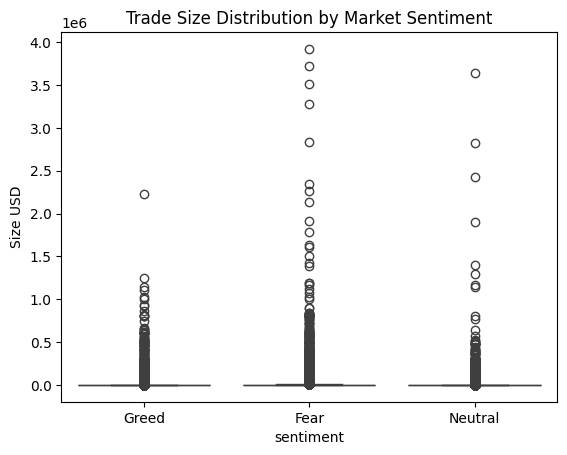

In [46]:

sns.boxplot(x='sentiment', y='Size USD', data=merged)

plt.title("Trade Size Distribution by Market Sentiment")

plt.show()

Insight:

Traders take larger positions in Fear conditions, reflecting higher risk appetite during volatility. In Greed, they prefer smaller but more frequent trades, while Neutral sentiment keeps both size and activity subdued.

#***Asset Preference by Sentiment***

In [49]:

asset_pref = merged.groupby(['sentiment','Coin']).size().reset_index(name='Trade_Count')

In [52]:
top_assets = asset_pref.groupby('sentiment').apply(lambda x: x.sort_values('Trade_Count', ascending=False).head(5))
print(top_assets)

              sentiment  Coin  Trade_Count
sentiment                                 
Fear      76       Fear  HYPE        38229
          57       Fear   BTC        11635
          2        Fear  @107         6981
          115      Fear   SOL         5792
          65       Fear   ETH         4243
Greed     143     Greed  @107        18801
          257     Greed  HYPE        12452
          226     Greed   BTC         9676
          241     Greed   ETH         5598
          315     Greed   SOL         3499
Neutral   423   Neutral  HYPE        17324
          399   Neutral   BTC         4753
          355   Neutral  @107         4210
          472   Neutral   SOL         1400
          409   Neutral   ETH         1317


/tmp/ipykernel_217/4143487100.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_assets = asset_pref.groupby('sentiment').apply(lambda x: x.sort_values('Trade_Count', ascending=False).head(5))


([0, 1, 2, 3, 4],
 [Text(0, 0, 'HYPE'),
  Text(1, 0, 'BTC'),
  Text(2, 0, '@107'),
  Text(3, 0, 'SOL'),
  Text(4, 0, 'ETH')])

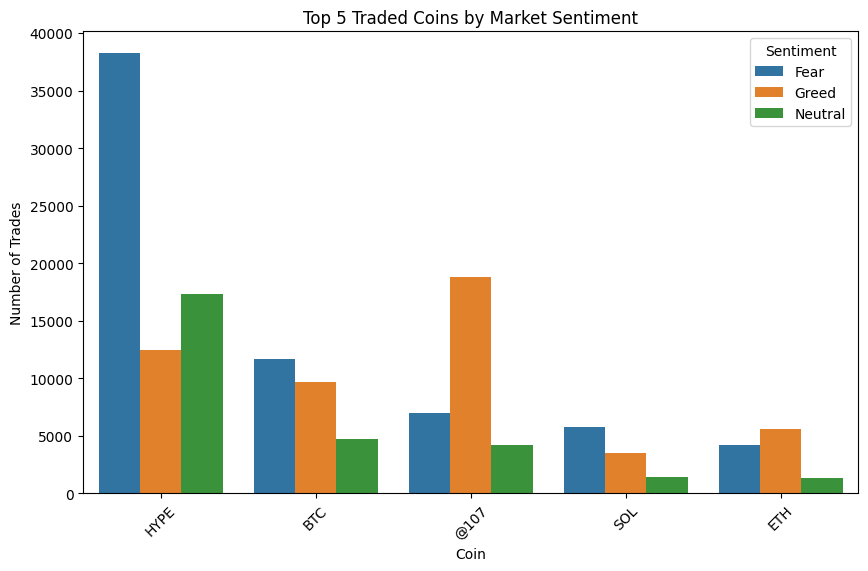

In [53]:
plt.figure(figsize=(10,6))
sns.barplot(x='Coin', y='Trade_Count', hue='sentiment', data=top_assets)
plt.title("Top 5 Traded Coins by Market Sentiment")
plt.ylabel("Number of Trades")
plt.xlabel("Coin")
plt.legend(title="Sentiment")
plt.xticks(rotation=45)

Insight:

Traders chase speculative coins (HYPE, @107) when sentiment is extreme, while established assets (BTC, ETH) remain secondary. This reveals a momentum‑driven bias in trader behavior, where sentiment amplifies preference for high‑risk tokens.

#Final Insights Summary: Trader Performance vs Market Sentiment

1. Profitability Patterns

Average profitability is highest in Greed markets (~54) , followed by Fear (~49).

Neutral markets underperform (~35).

Extreme sentiment creates more exploitable trading opportunities.

2. Trading Outcomes

Losses consistently exceed profits across all sentiments (e.g., Greed: 52k Loss vs 38k Profit).

Sustaining profitability remains structurally difficult, reinforcing the importance of risk management.

3. Trade Direction

Buy and Sell trades are balanced overall, but Sell trades slightly dominate in Greed and Fear.

Traders lean toward profit‑taking or hedging when sentiment is strong.

4. Risk Appetite

Fear markets show the largest average trade size (~7.2k USD), with extreme outliers.

Greed favors smaller but more frequent trades, Neutral remains moderate.

Volatility drives larger positions, optimism drives participation.

5. Asset Preference

HYPE dominates Fear (38k trades) and Neutral (17k trades).

@107 leads Greed (18.8k trades), while BTC and ETH remain secondary.

Traders chase speculative tokens under extreme sentiment, revealing a momentum‑driven bias.